In [ ]:
from sklearn.datasets import load_wine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error

print("Возьмем стандартную БДшку")
wine = load_wine()
x_wine = wine.data
y_wine = wine.target  # Вектор целевых меток
target_names_wine = wine.target_names
feature_names_wine = wine.feature_names

# Создаем DataFrame для удобства просмотра
df_wine = pd.DataFrame(x_wine, columns=feature_names_wine)
df_wine['target'] = y_wine
print("Первые 5 строк:")
print(df_wine.head())

Возьмем стандартную БДшку
Первые 5 строк:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_di


Число объектов: 178
Число признаков: 13
Названия признаков: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Построение гистограмм распределения признаков...


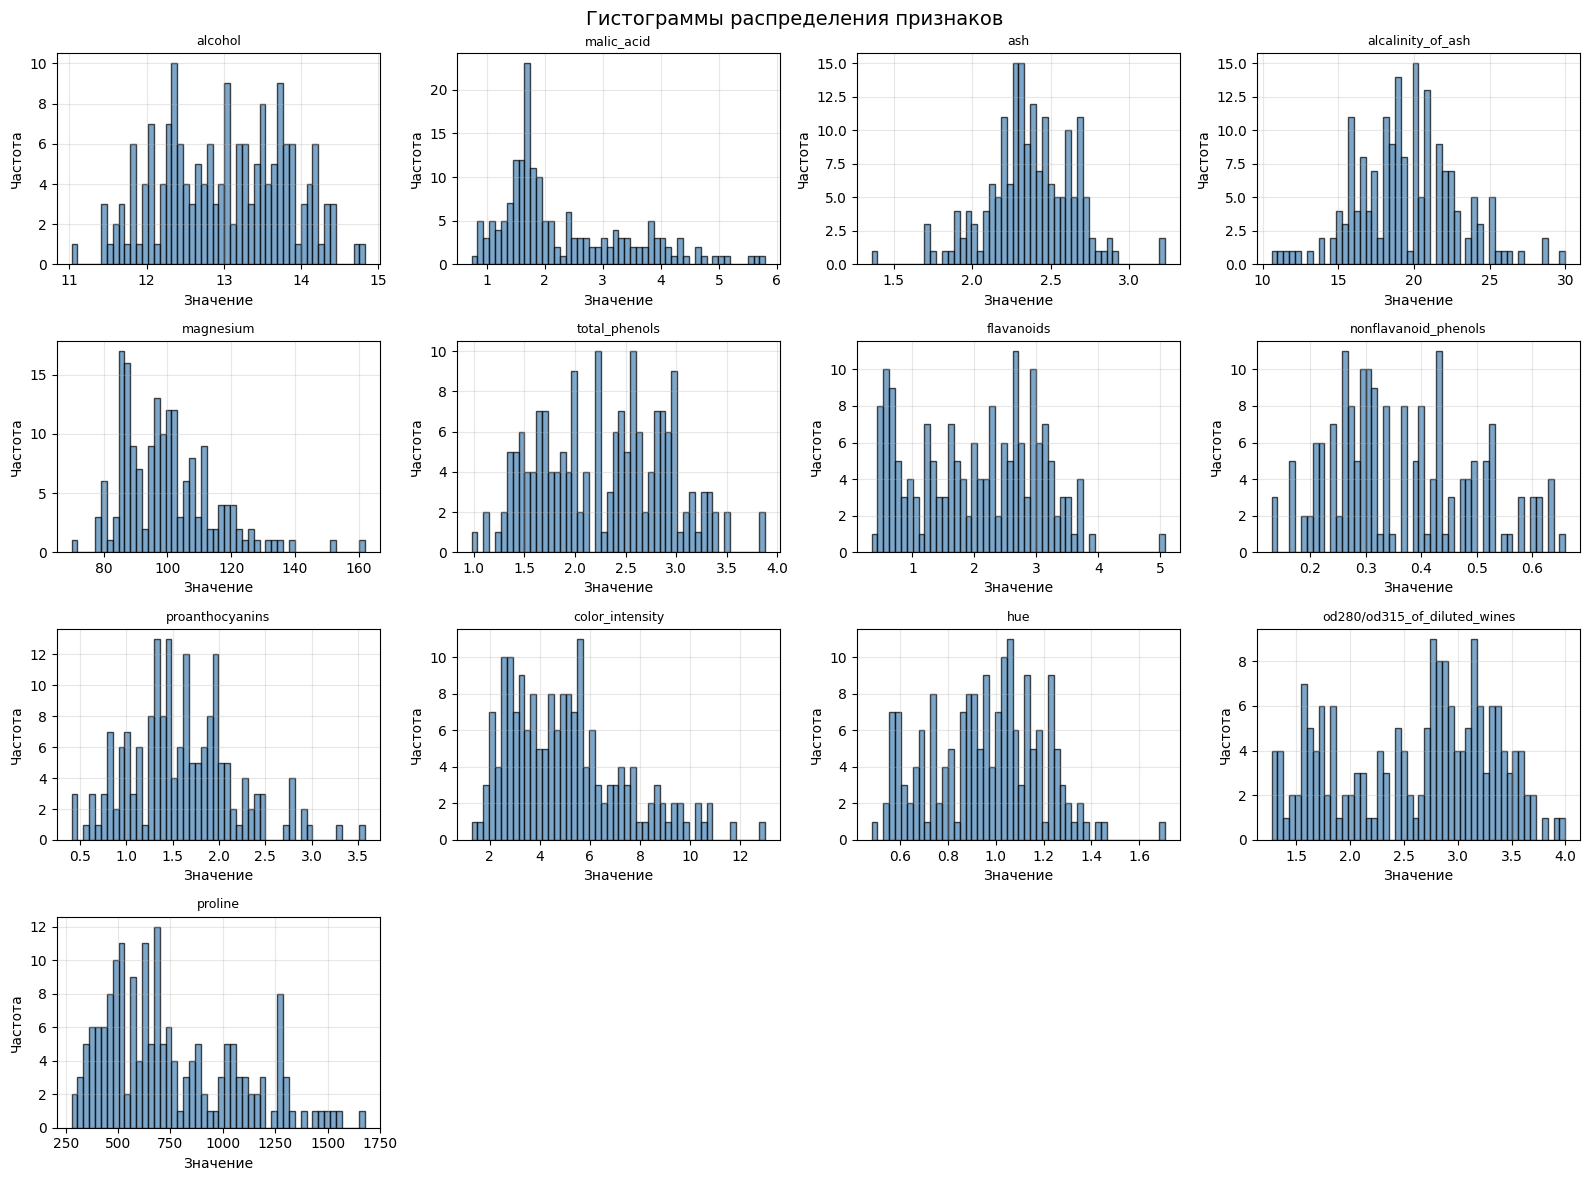


Построение матрицы корреляций признаков...


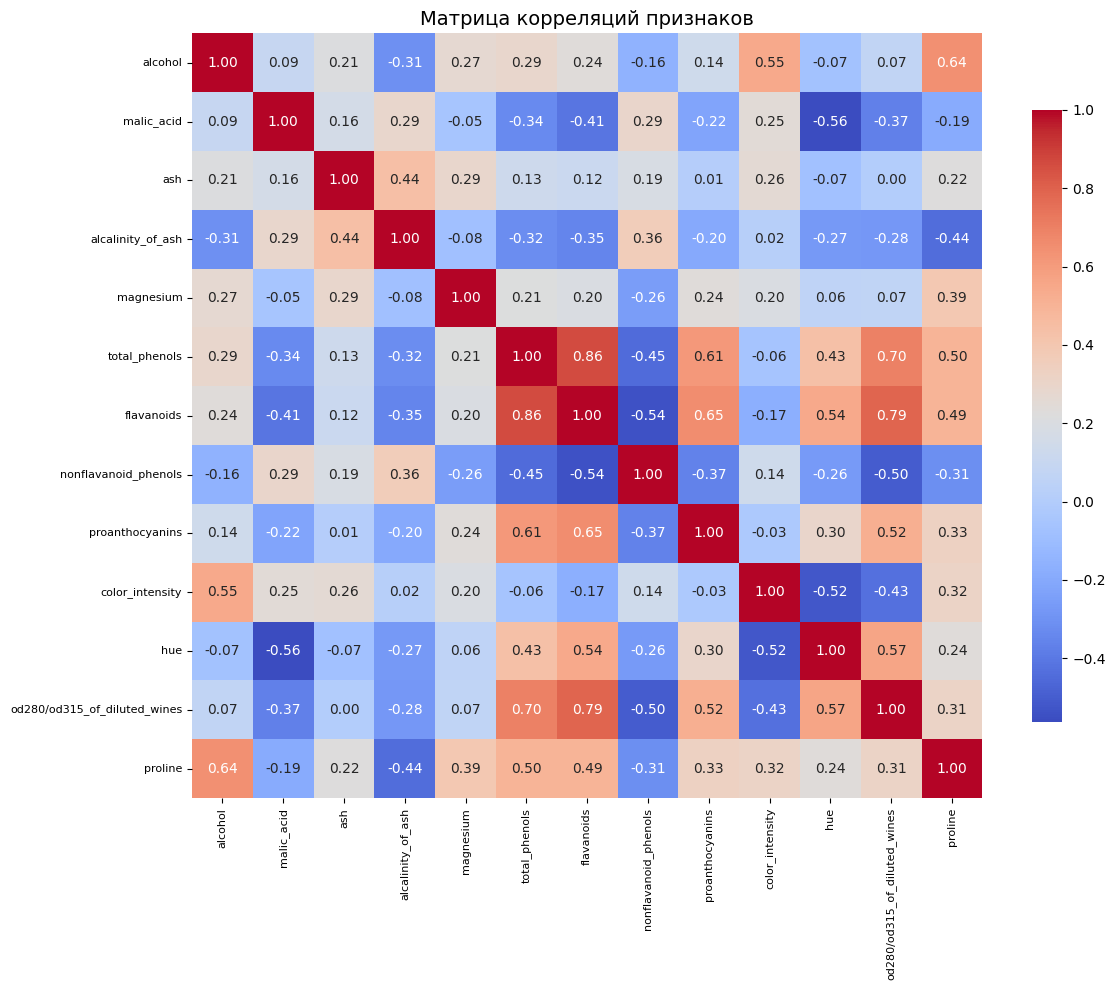


Анализ корреляций:

Сильно коррелированные признаки (|r| > 0.8):
  total_phenols <-> flavanoids: 0.865

Вывод: Присутствует 1 сильно коррелированный признак, что указывает на избыточность информации.


In [ ]:
# Задание 1. Геометрия данных в пространстве признаков

objects_count, features_count = x_wine.shape
print(f"\nЧисло объектов: {objects_count}")
print(f"Число признаков: {features_count}")
print(f"Названия признаков: {feature_names_wine}")

print("\nПостроение гистограмм распределения признаков...")
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()
for i, feature in enumerate(feature_names_wine[:min(13, features_count)]):
    axes[i].hist(x_wine[:, i], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')
    axes[i].grid(True, alpha=0.3)

for i in range(features_count, len(axes)):
    axes[i].axis('off')
plt.suptitle('Гистограммы распределения признаков', fontsize=14)
plt.tight_layout()
plt.show()

print("\nПостроение матрицы корреляций признаков...")

corr_matrix = np.corrcoef(x_wine.T)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', # annot - анотация, fmt - числа после запятоц, cmap - цветовая палитра
            xticklabels=feature_names_wine, yticklabels=feature_names_wine, # xticklabels / yticklabels - откуда брать подписи на оси
            cbar_kws={'shrink': 0.8}) # Уменьшает боковую шкалу чуть-чуть
plt.title('Матрица корреляций признаков', fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print("\nАнализ корреляций:")
strong_correlations = []
for i in range(features_count):
    for j in range(i+1, features_count):
        if abs(corr_matrix[i, j]) > 0.8:
            strong_correlations.append((feature_names_wine[i], feature_names_wine[j], corr_matrix[i, j]))

if strong_correlations:
    print("\nСильно коррелированные признаки (|r| > 0.8):")
    for f1, f2, corr in strong_correlations:
        print(f"  {f1} <-> {f2}: {corr:.3f}")
    print("\nВывод: Присутствует 1 сильно коррелированный признак, что указывает на избыточность информации.")
else:
    print("\nСильно коррелированных признаков не обнаружено.")


Стандартизация данных...
Средние после преобразования:
 [ 7.84141790e-15  2.44498554e-16 -4.05917497e-15 -7.11041712e-17
 -2.49488320e-17 -1.95536471e-16  9.44313292e-16 -4.17892936e-16
 -1.54059038e-15 -4.12903170e-16  1.39838203e-15  2.12688793e-15
 -6.98567296e-17]

Стандартные отклонения после преобразования:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

PCA без sklearn

Первые 5 собственных значений:
  λ1 = 4.7324
  λ2 = 2.5111
  λ3 = 1.4542
  λ4 = 0.9242
  λ5 = 0.8580

Доля объясненной дисперсии (первые 5 компонент):
  PC1: 0.3620 (36.20%)
  PC2: 0.1921 (19.21%)
  PC3: 0.1112 (11.12%)
  PC4: 0.0707 (7.07%)
  PC5: 0.0656 (6.56%)

Собственные значения (наша реализация):
[4.73243698 2.51108093 1.45424187 0.92416587 0.85804868]

Собственные значения (sklearn):
[4.73243698 2.51108093 1.45424187 0.92416587 0.85804868]

Доля объясненной дисперсии (наша реализация):
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294]

Доля объясненной дисперсии (sklearn):
[0.36198848 0.1920749  0.1112

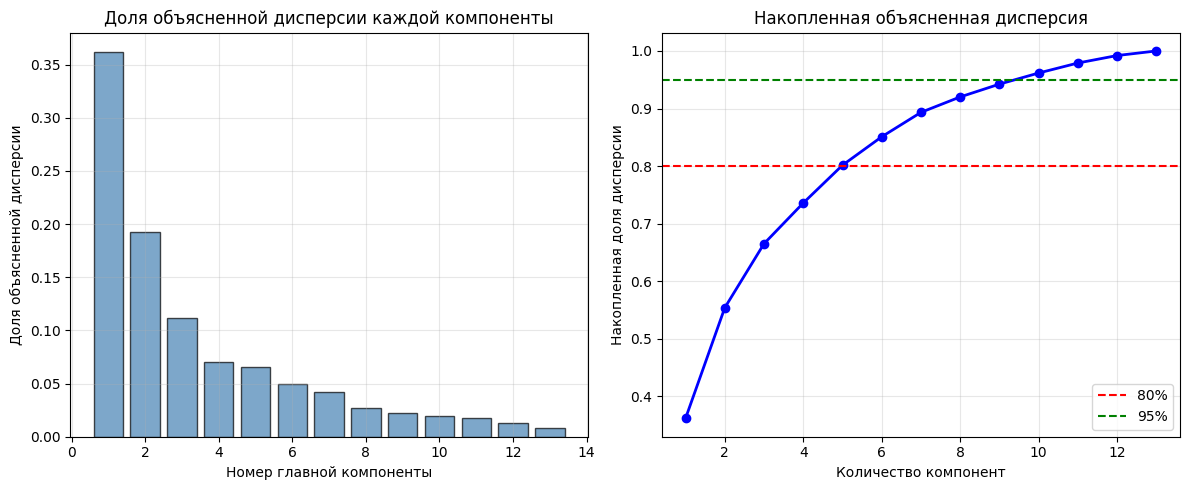

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA

print("\nСтандартизация данных...")
X_scaled = (x_wine - np.mean(x_wine, axis=0)) / np.std(x_wine, axis=0)
print("Средние после преобразования:\n", np.mean(X_scaled, axis=0))
print("\nСтандартные отклонения после преобразования:\n", np.std(X_scaled, axis=0))

print("\nPCA без sklearn")

cov_matrix = np.zeros((features_count, features_count))
for i in range(features_count):
    for j in range(features_count):
        cov_matrix[i, j] = np.sum(X_scaled[:, i] * X_scaled[:, j]) / (X_scaled.shape[0] - 1)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix) # Внутри там QR-разложение
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

W_full = eigenvectors[:, :features_count] # матрица проекций для перехода в пространство с меньшим кол-вом измерений
X_pca_full = X_scaled.dot(W_full)

explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio) # для отрисовки кумуляты объясненной дисперсии

print("\nПервые 5 собственных значений:")
for i in range(min(5, features_count)):
    print(f"  λ{i+1} = {eigenvalues[i]:.4f}")

print("\nДоля объясненной дисперсии (первые 5 компонент):")
for i in range(min(5, features_count)):
    print(f"  PC{i+1}: {explained_variance_ratio[i]:.4f} ({explained_variance_ratio[i]*100:.2f}%)")



scaler = StandardScaler()
X_scaled_sklearn = scaler.fit_transform(x_wine)
pca_sklearn = SklearnPCA(n_components=features_count)
X_pca_sklearn = pca_sklearn.fit_transform(X_scaled_sklearn)

print("\nСобственные значения (наша реализация):")
print(eigenvalues[:5])
print("\nСобственные значения (sklearn):")
print(pca_sklearn.explained_variance_[:5])

print("\nДоля объясненной дисперсии (наша реализация):")
print(explained_variance_ratio[:5])
print("\nДоля объясненной дисперсии (sklearn):")
print(pca_sklearn.explained_variance_ratio_[:5])

correlation = np.corrcoef(X_pca_full[:, 0], X_pca_sklearn[:, 0])[0, 1]
print("\nКорреляция между PC1 (наша реализация) и PC1 (sklearn): ", correlation)
if abs(correlation) > 0.999:
    print("Результаты идентичны (возможно с обратным знаком)")
else:
    print("Есть небольшие различия в реализации")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio,
        alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объясненной дисперсии')
plt.title('Доля объясненной дисперсии каждой компоненты')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
         'bo-', linewidth=2, markersize=6)
plt.axhline(y=0.8, color='r', linestyle='--', label='80%')
plt.axhline(y=0.95, color='g', linestyle='--', label='95%')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная доля дисперсии')
plt.title('Накопленная объясненная дисперсия')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_components_80 = np.argmax(cumulative_variance >= 0.8) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

| <font size="5">English Name | <font size="5">Перевод на русский |
| :--- | :--- |
| <font size="5">alcohol</font> | <font size="5">алкоголь |
| <font size="5">malic_acid | <font size="5">яблочная кислота |
| <font size="5">ash | <font size="5">зола |
| <font size="5">alcalinity_of_ash | <font size="5">щелочность золы |
| <font size="5">magnesium | <font size="5">магний |
| <font size="5">total_phenols | <font size="5">общее количество фенолов |
| <font size="5">flavanoids | <font size="5">флавоноиды |
| <font size="5">nonflavanoid_phenols | <font size="5">нефлавоноидные фенолы |
| <font size="5">proanthocyanins | <font size="5">проантоцианины |
| <font size="5">color_intensity | <font size="5">интенсивность цвета |
| <font size="5">hue | <font size="5">оттенок |
| <font size="5">od280/od315_of_diluted_wines | <font size="5">разбавленный спирт 280/315 |
| <font size="5">proline | <font size="5">пролин |

In [ ]:
# Задание 3. Интерпретация главных компонент

n_components_interp = min(3, features_count) # Будет 3 компоненты
components_df = pd.DataFrame(
    eigenvectors[:, :n_components_interp],
    index=feature_names_wine,
    columns=[f'PC{i+1}' for i in range(n_components_interp)]
)

print("\nКоэффициенты признаков в первых трех компонентах:")
print(components_df.round(4))

print("\nПризнаки с наибольшим вкладом в каждую компоненту:")

for i in range(n_components_interp):
    pc_name = f'PC{i+1}'
    print(f"\n{pc_name}:")

    top_positive = components_df[pc_name].nlargest(3)
    print("Наибольший положительный вклад:")
    for feat, val in top_positive.items():
        print(f"{feat}: {val:.4f}")

    top_negative = components_df[pc_name].nsmallest(3)
    print("\nНаибольший отрицательный вклад:")
    for feat, val in top_negative.items():
        print(f"{feat}: {val:.4f}")

print("\n3. Признаки, которые практически не влияют на первые компоненты:")
low_impact = components_df[['PC1', 'PC2', 'PC3']].abs().sum(axis=1).nsmallest(3)
for feat, val in low_impact.items():
    print(f"   - {feat}: суммарный вклад = {val:.4f}")


Коэффициенты признаков в первых трех компонентах:
                                 PC1     PC2     PC3
alcohol                      -0.1443 -0.4837 -0.2074
malic_acid                    0.2452 -0.2249  0.0890
ash                           0.0021 -0.3161  0.6262
alcalinity_of_ash             0.2393  0.0106  0.6121
magnesium                    -0.1420 -0.2996  0.1308
total_phenols                -0.3947 -0.0650  0.1462
flavanoids                   -0.4229  0.0034  0.1507
nonflavanoid_phenols          0.2985 -0.0288  0.1704
proanthocyanins              -0.3134 -0.0393  0.1495
color_intensity               0.0886 -0.5300 -0.1373
hue                          -0.2967  0.2792  0.0852
od280/od315_of_diluted_wines -0.3762  0.1645  0.1660
proline                      -0.2868 -0.3649 -0.1267

Признаки с наибольшим вкладом в каждую компоненту:

PC1:
Наибольший положительный вклад:
nonflavanoid_phenols: 0.2985
malic_acid: 0.2452
alcalinity_of_ash: 0.2393

Наибольший отрицательный вклад:
flavanoids

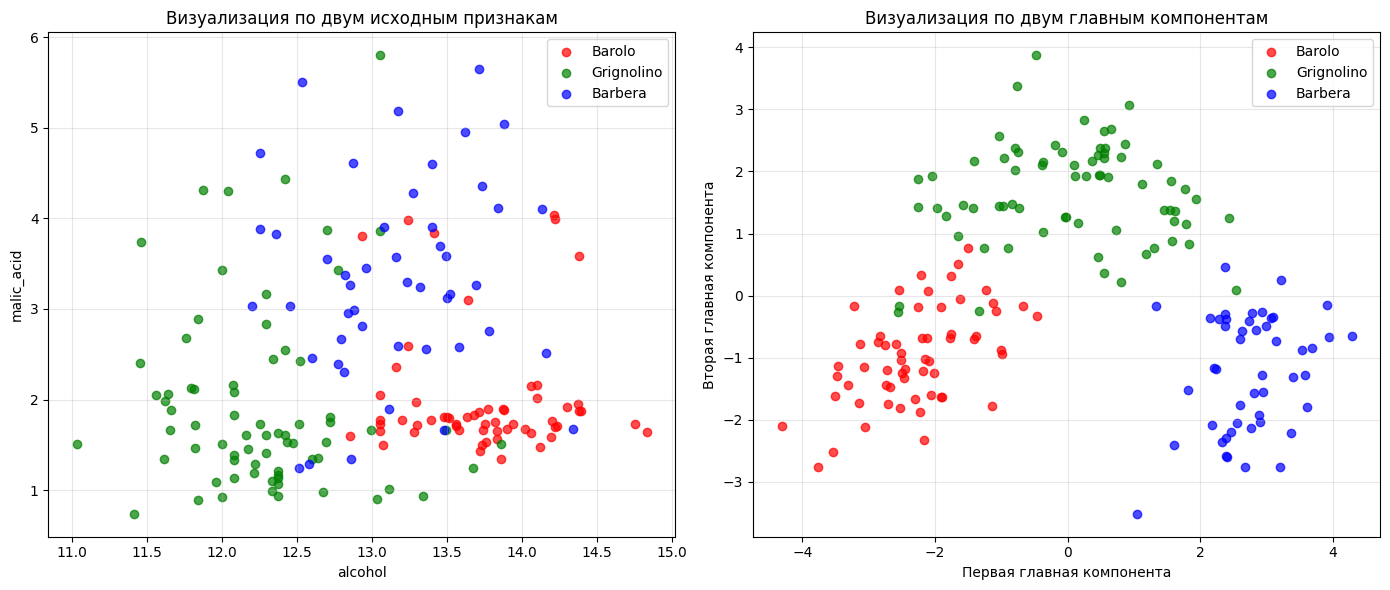

In [ ]:
# Задание 4. Визуализация данных

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
colors = ['red', 'green', 'blue']
class_names = ['Barolo', 'Grignolino', 'Barbera']
for i, target_name in enumerate(target_names_wine):
    plt.scatter(x_wine[y_wine == i, 0], x_wine[y_wine == i, 1],
                color=colors[i], label=class_names[i], alpha=0.7)
plt.xlabel(feature_names_wine[0])
plt.ylabel(feature_names_wine[1])
plt.title('Визуализация по двум исходным признакам')
plt.legend()
plt.grid(True, alpha=0.3)

X_pca2 = X_scaled.dot(eigenvectors[:, :2])
plt.subplot(1, 2, 2)
for i, target_name in enumerate(target_names_wine):
    plt.scatter(X_pca2[y_wine == i, 0], X_pca2[y_wine == i, 1],
                color=colors[i], label=class_names[i], alpha=0.7)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Визуализация по двум главным компонентам')
plt.legend()
plt.grid(True, alpha=0.3)

# Barolo (Бароло) — класс 0
# Grignolino (Гриньолино) — класс 1
# Barbera (Барбера) — класс 2

plt.tight_layout()
plt.show()


Вычисление t-SNE с tsne_params=5...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



Вычисление t-SNE с tsne_params=30...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



Вычисление t-SNE с tsne_params=50...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


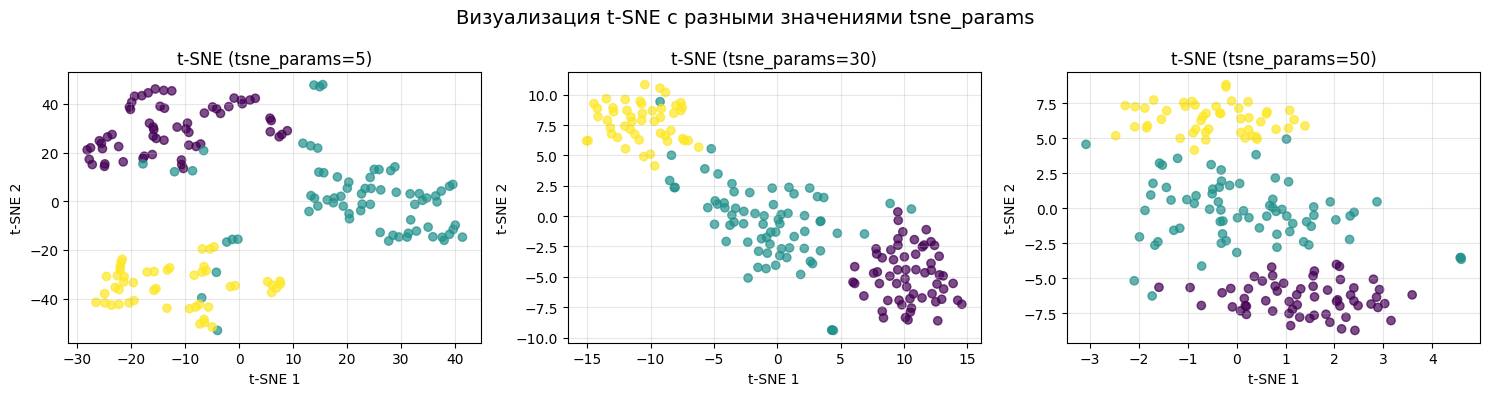


Вычисление UMAP с n_neighbors=5, min_dist=0.1...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Вычисление UMAP с n_neighbors=30, min_dist=0.5...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Вычисление UMAP с n_neighbors=50, min_dist=0.1...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


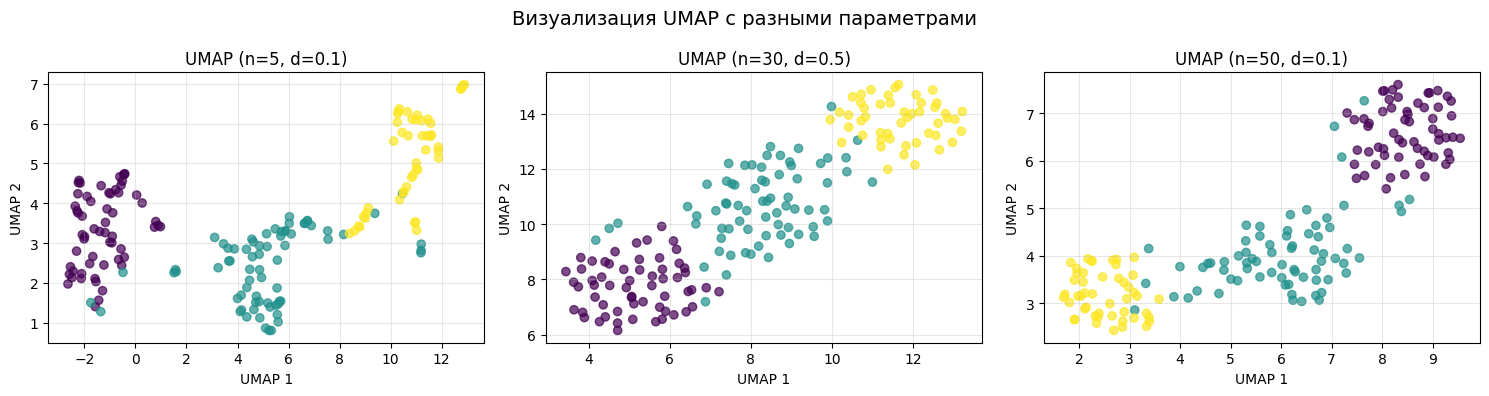

In [ ]:
# Задание 5. Нелинейные методы снижения размерности

tsne_params = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, param in enumerate(tsne_params):
    print(f"\nВычисление t-SNE с tsne_params={param}...")
    tsne = TSNE(n_components=2, perplexity=param, random_state=42, n_iter=1000)
    X_tsne = tsne.fit_transform(X_scaled)

    axes[idx].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_wine, cmap='viridis', alpha=0.7)
    axes[idx].set_title(f't-SNE (tsne_params={param})')
    axes[idx].set_xlabel('t-SNE 1')
    axes[idx].set_ylabel('t-SNE 2')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Визуализация t-SNE с разными значениями tsne_params', fontsize=14)
plt.tight_layout()
plt.show()

umap_params = [
    {'n_neighbors': 5, 'min_dist': 0.1},
    {'n_neighbors': 30, 'min_dist': 0.5},
    {'n_neighbors': 50, 'min_dist': 0.1}
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, params in enumerate(umap_params):
    print(f"\nВычисление UMAP с n_neighbors={params['n_neighbors']}, min_dist={params['min_dist']}...")
    reducer = umap.UMAP(n_components=2, random_state=42, **params)
    X_umap = reducer.fit_transform(X_scaled)

    axes[idx].scatter(X_umap[:, 0], X_umap[:, 1], c=y_wine, cmap='viridis', alpha=0.7)
    title = f'UMAP (n={params["n_neighbors"]}, d={params["min_dist"]})'
    axes[idx].set_title(title)
    axes[idx].set_xlabel('UMAP 1')
    axes[idx].set_ylabel('UMAP 2')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Визуализация UMAP с разными параметрами', fontsize=14)
plt.tight_layout()
plt.show()

При k =  2
Размерность после преобразования:  (178, 2)
Восстановленная размерность:  (178, 13)
Ошибка восстановления (MSE):  0.4459366164306474
При k =  5
Размерность после преобразования:  (178, 5)
Восстановленная размерность:  (178, 13)
Ошибка восстановления (MSE):  0.19837707244452127
При k =  10
Размерность после преобразования:  (178, 10)
Восстановленная размерность:  (178, 13)
Ошибка восстановления (MSE):  0.038302831554935794
При k =  15
Размерность после преобразования:  (178, 13)
Восстановленная размерность:  (178, 13)
Ошибка восстановления (MSE):  2.720036554808906e-30
------------------------------------------------------------
Число компонент      Ошибка восстановления    
------------------------------------------------------------
2                    0.445937                 
5                    0.198377                 
10                   0.038303                 
15                   0.000000                 
---------------------------------------------------------

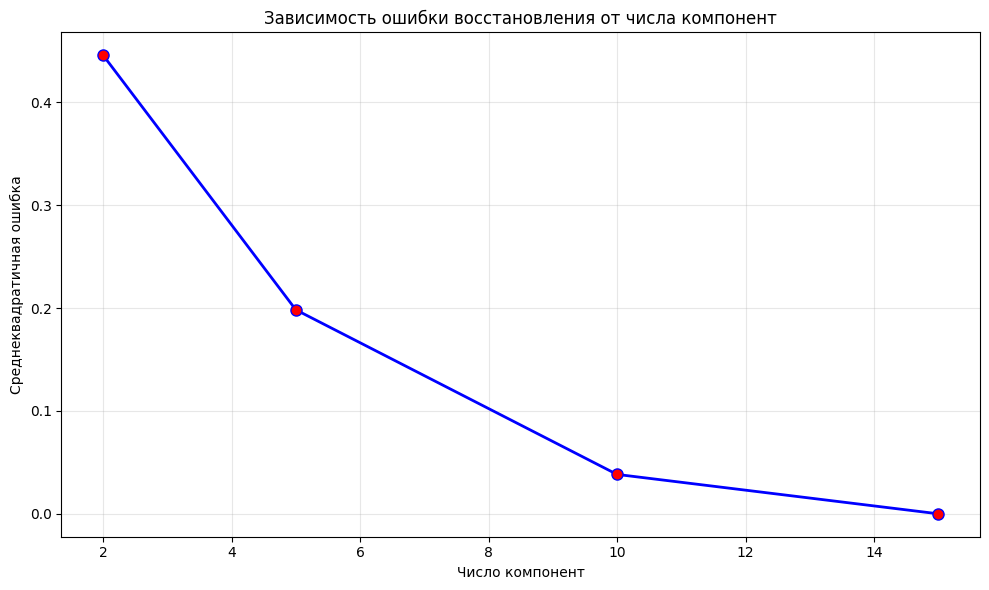

In [ ]:
# Задание 6. Исследование степени сжатия данных

# 6.1 Снижение размерности
k_values = [2, 5, 10, 15]
mse_values = []

for k in k_values:
    print("При k = ", k)
    W_k = eigenvectors[:, :k]
    X_pca_k = X_scaled.dot(W_k)
    print("Размерность после преобразования: ", X_pca_k.shape)

# 6.2 Восстановление данных
    X_reconstructed = X_pca_k.dot(W_k.T)
    print("Восстановленная размерность: ", X_reconstructed.shape)

    mse = mean_squared_error(X_scaled, X_reconstructed)
    mse_values.append(mse)
    print("Ошибка восстановления (MSE): ", mse)

# 6.3 Оценка ошибки восстановления
print("-"*60)
print(f"{'Число компонент':<20} {'Ошибка восстановления':<25}")
print("-"*60)
for k, mse in zip(k_values, mse_values):
    print(f"{k:<20} {mse:<25.6f}")
print("-"*60)

# 6.4 Визуальный анализ
plt.figure(figsize=(10, 6))
plt.plot(k_values, mse_values, 'bo-', linewidth=2, markersize=8, markerfacecolor='red')
plt.xlabel('Число компонент')
plt.ylabel('Среднеквадратичная ошибка')
plt.title('Зависимость ошибки восстановления от числа компонент')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Задание 7. Итоговый анализ

## 1. Какую роль играет снижение размерности в анализе данных:
Уменьшение вычислительной сложности и требований к памяти;
Борьба с "проклятием размерности";
Улучшение визуализации многомерных данных;
Выявление скрытой структуры и закономерностей;
Уменьшение шума и избыточности в данных;
Улучшение производительности некоторых алгоритмов машинного обучения;

## 2. Всегда ли уменьшение размерности полезно
Нет, не всегда. Потому-что
Потеря информации может быть критичной для некоторых задач;
Интерпретируемость может ухудшиться;
При малом объеме данных потеря информации может быть значительной;
Линейные методы могут не справиться со сложными нелинейными зависимостями;

## 3. В каких случаях линейные методы могут работать хуже нелинейных?
Данные имеют нелинейную структуру (например, лежат на искривленном многообразии);
Отношения между признаками нелинейны;
Важна локальная структура данных;
Данные имеют сложную топологию;

## 4. Какие преимущества и ограничения есть у методов PCA, t-SNE и UMAP?

PCA (Метод главных компонент):
<br>
Преимущества: быстрый, детерминированный, интерпретируемый
<br>
Ограничения: только линейные преобразования, чувствителен к выбросам
<br>
t-SNE:
<br>
Преимущества: отличная визуализация, сохраняет локальную структуру
<br>
Ограничения: медленный, недетерминированный, не имеет обратного преобразования
<br>
UMAP:
<br>
Преимущества: быстрее t-SNE, сохраняет и локальную, и глобальную структуру
<br>
Ограничения: сложнее в интерпретации, чувствителен к параметрам